In [1]:
from google.colab import files
uploaded = files.upload()

Saving WA_Fn-UseC_-HR-Employee-Attrition.csv to WA_Fn-UseC_-HR-Employee-Attrition.csv


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')

print("Shape:", df.shape)
print("\nColumns:", list(df.columns))
print("\nAttrition value counts:")
print(df['Attrition'].value_counts())
print(f"\nAttrition rate: {(df['Attrition']=='Yes').mean()*100:.1f}%")
df.head()

Shape: (1470, 35)

Columns: ['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Attrition value counts:
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition rate: 16.1%


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [3]:
# Check nulls
print("Nulls:", df.isnull().sum().sum())  # Should be 0

# Drop useless columns — same value for all rows
df.drop(['EmployeeCount', 'Over18', 'StandardHours'], axis=1, inplace=True)

# Convert Attrition to binary
df['Attrition_Binary'] = df['Attrition'].map({'Yes': 1, 'No': 0})

# Create age groups
df['Age_Group'] = pd.cut(df['Age'],
    bins=[18, 25, 35, 45, 60],
    labels=['18–25', '26–35', '36–45', '46–60'])

# Create experience groups
df['Experience_Group'] = pd.cut(df['YearsAtCompany'],
    bins=[0, 2, 5, 10, 40],
    labels=['0–2 years', '3–5 years', '6–10 years', '10+ years'])

print("Cleaned shape:", df.shape)

Nulls: 0
Cleaned shape: (1470, 35)


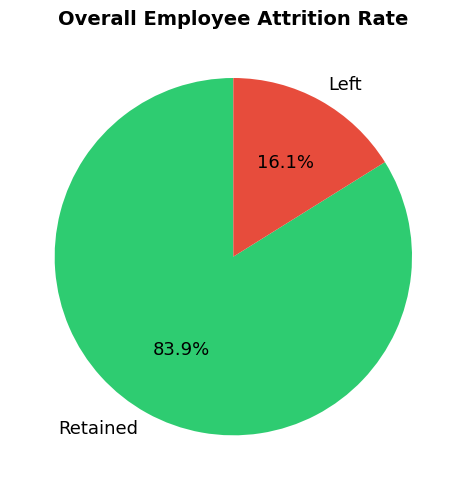

Total employees: 1470
Attrition rate: 16.1%


In [4]:
attrition_counts = df['Attrition'].value_counts()
colors = ['#2ECC71', '#E74C3C']

plt.figure(figsize=(7,5))
plt.pie(attrition_counts, labels=['Retained', 'Left'],
        colors=colors, autopct='%1.1f%%',
        startangle=90, textprops={'fontsize':13})
plt.title('Overall Employee Attrition Rate', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('attrition_overall.png', dpi=150)
plt.show()
print(f"Total employees: {len(df)}")
print(f"Attrition rate: {(df['Attrition']=='Yes').mean()*100:.1f}%")

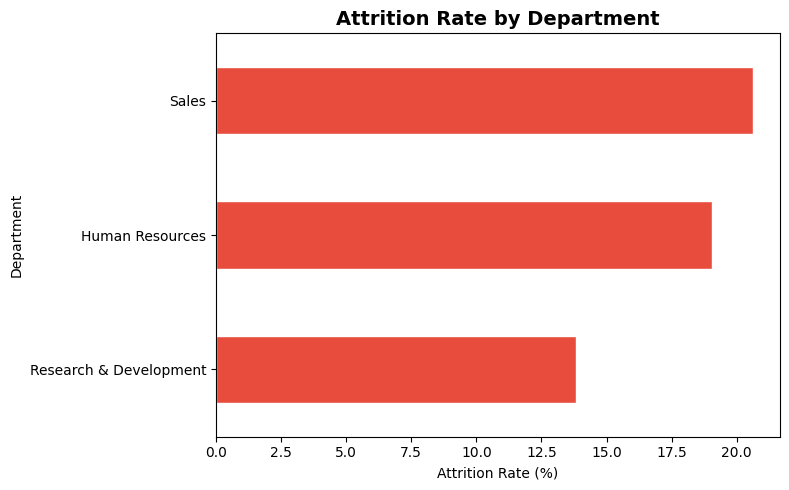

Department
Human Resources           19.0
Research & Development    13.8
Sales                     20.6
Name: Attrition_Binary, dtype: float64


In [5]:
dept_attrition = df.groupby('Department')['Attrition_Binary'].mean() * 100

plt.figure(figsize=(8,5))
dept_attrition.sort_values().plot(kind='barh', color='#E74C3C', edgecolor='white')
plt.title('Attrition Rate by Department', fontsize=14, fontweight='bold')
plt.xlabel('Attrition Rate (%)')
plt.tight_layout()
plt.savefig('attrition_by_department.png', dpi=150)
plt.show()
print(dept_attrition.round(1))

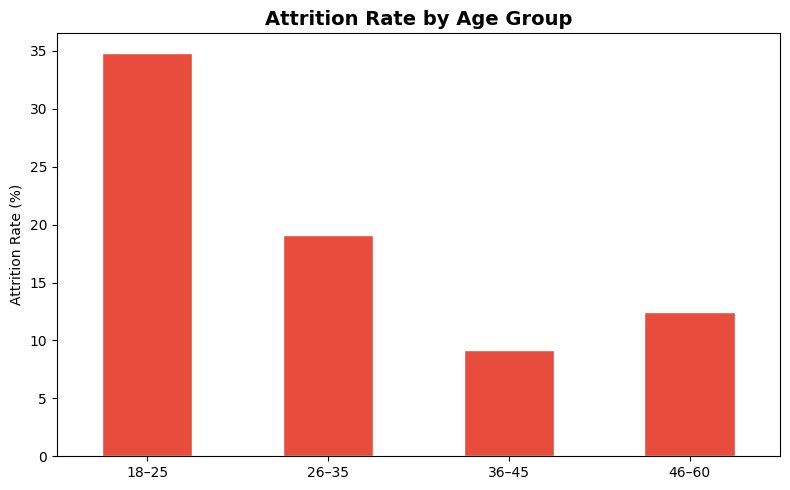

Age_Group
18–25    34.8
26–35    19.1
36–45     9.2
46–60    12.5
Name: Attrition_Binary, dtype: float64


In [6]:
age_attrition = df.groupby('Age_Group', observed=True)['Attrition_Binary'].mean() * 100

plt.figure(figsize=(8,5))
age_attrition.plot(kind='bar', color='#E74C3C', edgecolor='white')
plt.title('Attrition Rate by Age Group', fontsize=14, fontweight='bold')
plt.ylabel('Attrition Rate (%)')
plt.xlabel('')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('attrition_by_age.png', dpi=150)
plt.show()
print(age_attrition.round(1))

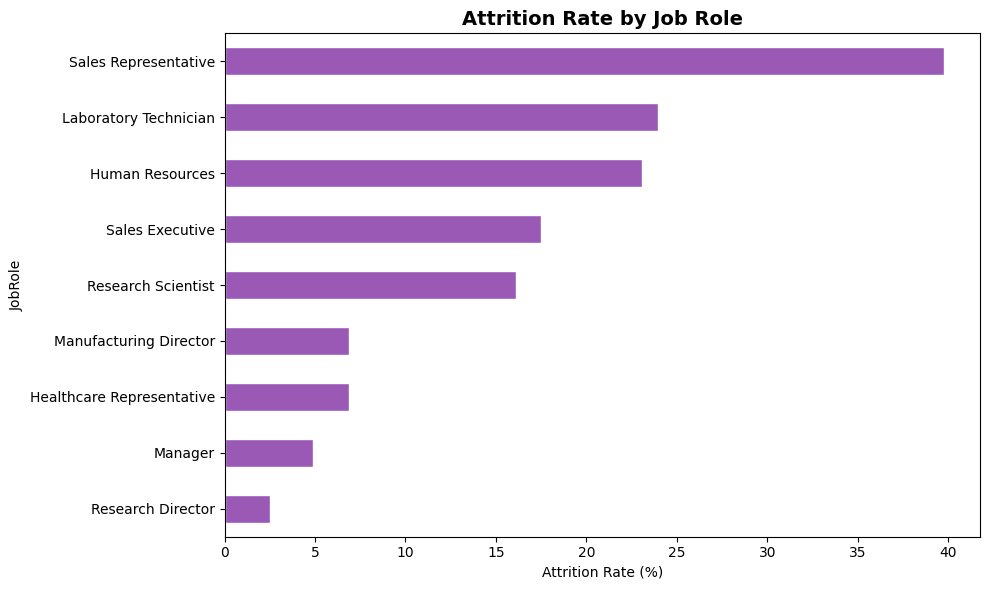

In [7]:
role_attrition = df.groupby('JobRole')['Attrition_Binary'].mean() * 100

plt.figure(figsize=(10,6))
role_attrition.sort_values().plot(kind='barh', color='#9B59B6', edgecolor='white')
plt.title('Attrition Rate by Job Role', fontsize=14, fontweight='bold')
plt.xlabel('Attrition Rate (%)')
plt.tight_layout()
plt.savefig('attrition_by_role.png', dpi=150)
plt.show()

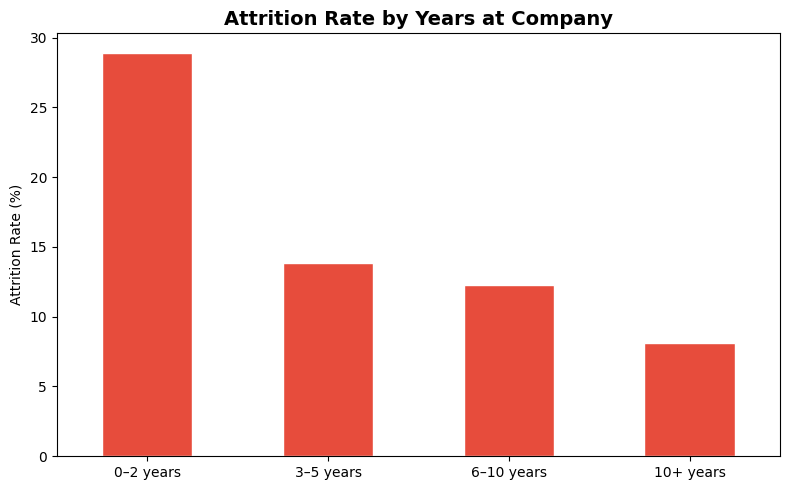

Experience_Group
0–2 years     28.9
3–5 years     13.8
6–10 years    12.3
10+ years      8.1
Name: Attrition_Binary, dtype: float64


In [8]:
exp_attrition = df.groupby('Experience_Group', observed=True)['Attrition_Binary'].mean() * 100

plt.figure(figsize=(8,5))
exp_attrition.plot(kind='bar', color='#E74C3C', edgecolor='white')
plt.title('Attrition Rate by Years at Company', fontsize=14, fontweight='bold')
plt.ylabel('Attrition Rate (%)')
plt.xlabel('')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('attrition_by_experience.png', dpi=150)
plt.show()
print(exp_attrition.round(1))

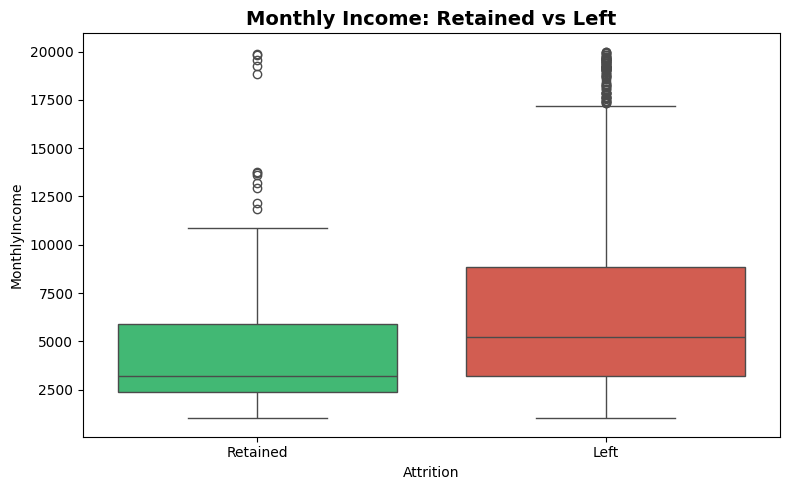

Avg income - Retained: $6,833 | Left: $4,787


In [9]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Attrition', y='MonthlyIncome',
            palette=['#2ECC71', '#E74C3C'])
plt.title('Monthly Income: Retained vs Left', fontsize=14, fontweight='bold')
plt.xticks([0,1], ['Retained', 'Left'])
plt.tight_layout()
plt.savefig('income_vs_attrition.png', dpi=150)
plt.show()

avg = df.groupby('Attrition')['MonthlyIncome'].mean()
print(f"Avg income - Retained: ${avg['No']:,.0f} | Left: ${avg['Yes']:,.0f}")

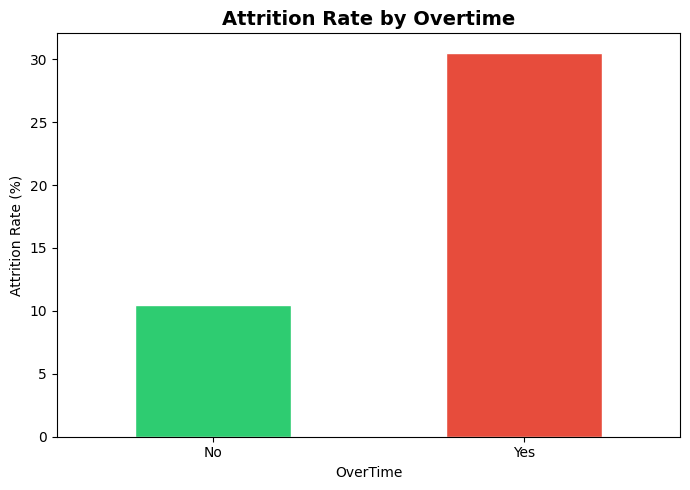

OverTime
No     10.4
Yes    30.5
Name: Attrition_Binary, dtype: float64


In [10]:
ot_attrition = df.groupby('OverTime')['Attrition_Binary'].mean() * 100

plt.figure(figsize=(7,5))
ot_attrition.plot(kind='bar', color=['#2ECC71', '#E74C3C'], edgecolor='white')
plt.title('Attrition Rate by Overtime', fontsize=14, fontweight='bold')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('attrition_by_overtime.png', dpi=150)
plt.show()
print(ot_attrition.round(1))
# Key finding: overtime employees churn at ~30% vs ~10% without overtime

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder

df_model = df.drop(['Attrition', 'Age_Group', 'Experience_Group'], axis=1).copy()

# Encode text columns
cat_cols = df_model.select_dtypes(include='object').columns
for col in cat_cols:
    df_model[col] = LabelEncoder().fit_transform(df_model[col])

X = df_model.drop('Attrition_Binary', axis=1)
y = df_model['Attrition_Binary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print(classification_report(y_test, model.predict(X_test)))

              precision    recall  f1-score   support

           0       0.89      0.98      0.93       255
           1       0.58      0.18      0.27        39

    accuracy                           0.87       294
   macro avg       0.73      0.58      0.60       294
weighted avg       0.85      0.87      0.84       294



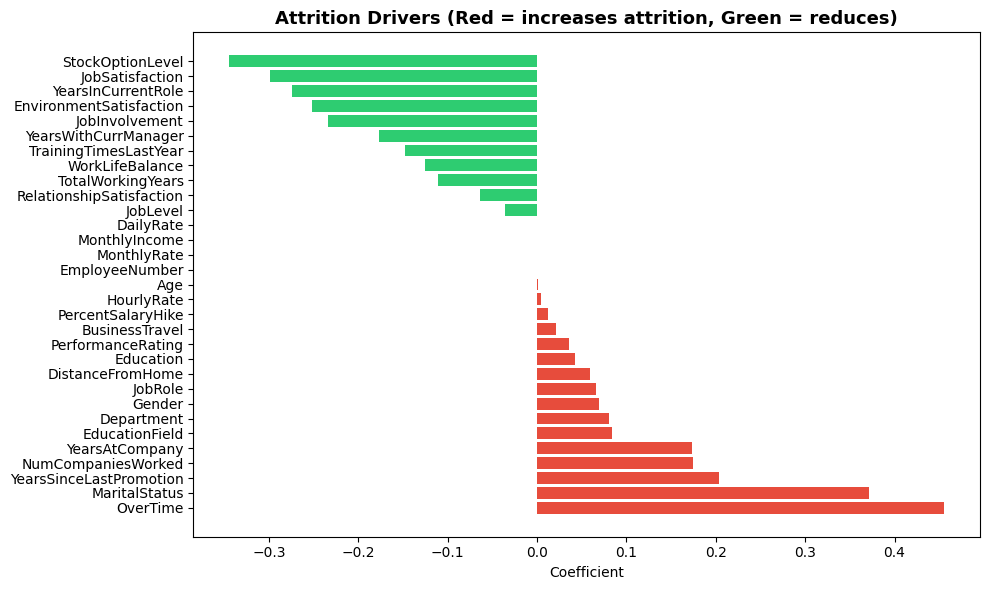

In [12]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
}).sort_values('Coefficient', ascending=False)

plt.figure(figsize=(10,6))
colors = ['#E74C3C' if c > 0 else '#2ECC71' for c in importance['Coefficient']]
plt.barh(importance['Feature'], importance['Coefficient'], color=colors)
plt.title('Attrition Drivers (Red = increases attrition, Green = reduces)',
          fontsize=13, fontweight='bold')
plt.xlabel('Coefficient')
plt.tight_layout()
plt.savefig('attrition_drivers.png', dpi=150)
plt.show()

In [13]:
df_export = df.copy()
df_export['Age_Group'] = df_export['Age_Group'].astype(str)
df_export['Experience_Group'] = df_export['Experience_Group'].astype(str)
df_export.to_csv('hr_attrition_cleaned.csv', index=False)

from google.colab import files
files.download('hr_attrition_cleaned.csv')
files.download('attrition_overall.png')
files.download('attrition_by_department.png')
files.download('attrition_by_age.png')
files.download('attrition_by_role.png')
files.download('attrition_by_experience.png')
files.download('income_vs_attrition.png')
files.download('attrition_by_overtime.png')
files.download('attrition_drivers.png')
print("All files downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All files downloaded!
